# **Project 2 (S005)** — Phishing Email Detector using Machine Learning

### Team 39 — G04

**Members:**
- BENAISSA Bochra  
- SAKRI Anfel
- LARMED Kahina 
- NEGAB Rania 
- HADBI Sarra


## Introduction

Phishing emails are one of the most common forms of cyber attacks, designed to trick users into revealing sensitive information. This project builds a machine learning pipeline to automatically detect phishing emails by analyzing their content, structure, and metadata.

The dataset used is **CEAS_08**, it contains **39,154 emails** including sender information, recipient information, date, and labels for spam/legitimate classification.

---
## Data Preprocessing
**Student:** HADBI Sarra | **Group:** 4

This section covers loading, exploring, and cleaning the raw dataset.  
The output is `cleaned_CEAS_08.csv`.

## Step 1: Load the Dataset
Import required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

load the raw dataset for initial inspection.

In [2]:
df = pd.read_csv('CEAS_08.csv')
print(f"Dataset loaded successfully")

Dataset loaded successfully


### 1. First Look at the Data

In [3]:
df.head()

,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1


**Key observations:**
- The dataset contains 7 columns: `sender`, `receiver`, `date`, `subject`, `body`, `label`, and `urls`.  
- The `label` column is our target: **1 = phishing, 0 = legitimate**.  
- The `urls` column appears to be binary (0 or 1), indicating the presence of a URL in the email.

### 2. Dataset Shape

In [4]:
rows, cols = df.shape
print(f"Rows : {rows}")
print(f"Columns : {cols}")

Rows : 39154
Columns : 7


We have **39,154 emails** in total across 7 columns.

### 3. Dataset Info (Column Names & Data Types)

In [5]:
print("Dataset info:\n")
df.info()

Dataset info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39154 entries, 0 to 39153
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sender    39154 non-null  object
 1   receiver  38692 non-null  object
 2   date      39154 non-null  object
 3   subject   39126 non-null  object
 4   body      39154 non-null  object
 5   label     39154 non-null  int64 
 6   urls      39154 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 2.1+ MB


`date` is stored as a `object` string, it must be converted to `datetime`. We also have some missing values detected in `receiver` and `subject`. These problems will be handled later.

## Step 2: Data Description
Explore the dataset statistically and understand the distribution of classes.

### 1. Basic Statistics

In [6]:
df.describe(include='all')

,sender,receiver,date,subject,body,label,urls
count,39154,38692,39154,39126,39154,39154.000000,39154.00000
unique,24578,3693,38658,15436,39154,NaN,NaN
top,qydlqcws-iacfym@issues.apache.org,user6@gvc.ceas-challenge.cc,"Thu, 07 Aug 2008 21:38:18 -0100",CNN.com Daily Top 10,Dear fellow Pythonistas!\n\nGuido has accepted...,NaN,NaN
freq,462,1375,8,2930,1,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,0.557848,0.66997
std,NaN,NaN,NaN,NaN,NaN,0.496649,0.47023
min,NaN,NaN,NaN,NaN,NaN,0.000000,0.00000
25%,NaN,NaN,NaN,NaN,NaN,0.000000,0.00000
50%,NaN,NaN,NaN,NaN,NaN,1.000000,1.00000
75%,NaN,NaN,NaN,NaN,NaN,1.000000,1.00000


**Key observations:**
- `sender`: most senders appear only once (24578 unique values), typical of phishing campaigns using throwaway addresses (addresses created specifically for one-time use and then abandoned).
- `subject`: "CNN.com Daily Top 10" appears 2,930 times (seems like a recurring newsletter pattern).
- `body`: every email has a completely unique body.
- `label`: mean of **0.56** confirms the slight class imbalance.
- `urls`: mean of **0.67** means roughly 2 out of 3 emails contain a URL.

### 2. Class Distribution (label column)

Class Distribution:
                Count  Percentage (%)
Phishing (1)    21842           55.78
Legitimate (0)  17312           44.22


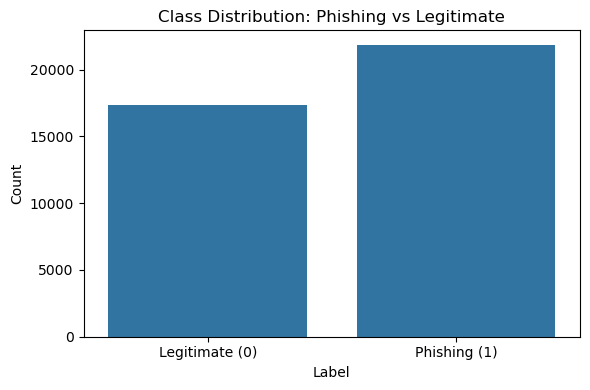

In [7]:
class_counts = df['label'].value_counts()
class_pct = df['label'].value_counts(normalize=True) * 100

class_summary = pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_pct.round(2)
})
class_summary.index = ['Phishing (1)', 'Legitimate (0)']

print("Class Distribution:")
print(class_summary)

# Plot
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df)
plt.xticks([0, 1], ['Legitimate (0)', 'Phishing (1)'])
plt.title('Class Distribution: Phishing vs Legitimate')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

We can clearly see that he dataset is slightly **imbalanced**.

### 3. URLs Column Overview

URL Distribution:
             Count  Percentage (%)
Has URL (1)  26232            67.0
No URL (0)   12922            33.0


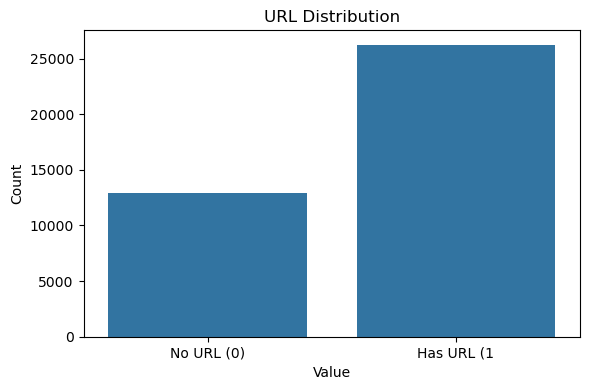

In [8]:
url_counts = df['urls'].value_counts()
url_pct = df['urls'].value_counts(normalize=True) * 100

url_summary = pd.DataFrame({
    'Count': url_counts,
    'Percentage (%)': url_pct.round(2)
})
url_summary.index = ['Has URL (1)', 'No URL (0)']

print("URL Distribution:")
print(url_summary)

# Plot
plt.figure(figsize=(6, 4))
sns.countplot(x='urls', data=df)
plt.xticks([0, 1], ['No URL (0)', 'Has URL (1'])
plt.title('URL Distribution')
plt.xlabel('Value')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 4. Check Missing Values

In [9]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

print(missing_df)

          Missing Count  Missing %
sender                0       0.00
receiver            462       1.18
date                  0       0.00
subject              28       0.07
body                  0       0.00
label                 0       0.00
urls                  0       0.00


Only `receiver` and `subject` have missing values and both are **minor**. `body` and `label` are complete with no missing values, which is critical since they are the main inputs for training. Therefore, we will handle our missing values by filling `receiver` with `'unknown'` and `subject` with `'no subject'`, preserving all rows since no data is too incomplete to keep.

### 5. Check Duplicates

In [10]:
dupes = df.duplicated().sum()
print(f"Duplicate rows found: {dupes}")

Duplicate rows found: 0


Thus, our dataset **does not contain** any duplicate rows.

## Step 3: Data Cleaning
Handle missing values, clean the text columns and convert data types when needed.

### 1. Handle Missing Values
- `receiver`: 462 missing (1.18%) → fill with `'unknown'`
- `subject`: 28 missing (0.07%) → fill with `'no subject'`

In [11]:
df['receiver'] = df['receiver'].fillna('unknown')
df['subject']  = df['subject'].fillna('no subject')

print("Missing values handled.")
print(f"Remaining nulls:\n{df.isnull().sum()}")

Missing values handled.
Remaining nulls:
sender      0
receiver    0
date        0
subject     0
body        0
label       0
urls        0
dtype: int64


### 2. Clean Text Columns (`subject` and `body`)
The raw `body` and `subject` columns are **preserved as-is** for feature engineering,
in order to extract HTML tags, URLs, and structural features directly from them.

For text vectorization, we will create separate cleaned versions: `subject_clean` and `body_clean`

Cleaning applied:
1. Lowercase all text
2. Remove extra whitespace / newlines / tabs
3. Remove non-ASCII characters
4. Remove special characters

In [12]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    # Lowercase
    text = text.lower()
    # Remove non-ASCII characters
    text = text.encode('ascii', errors='ignore').decode()
    # Remove special characters (keep letters, digits, spaces)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    # Remove extra whitespace / newlines / tabs
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['subject_clean'] = df['subject'].apply(clean_text)
df['body_clean']    = df['body'].apply(clean_text)

print("Clean text columns created (raw columns untouched).")
print("\nRaw body sample (first 200 chars):")
print(df['body'].iloc[2][:200])
print("\nCleaned body sample (first 200 chars):")
print(df['body_clean'].iloc[2][:200])

Clean text columns created (raw columns untouched).

Raw body sample (first 200 chars):
>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+= >THE DAILY TOP 10 >from CNN.com >Top videos and stories as of: Aug  1, 2008  3:58 PM EDT >+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=

Cleaned body sample (first 200 chars):
the daily top 10 from cnn com top videos and stories as of aug 1 2008 3 58 pm edt top 10 videos 1 montauk monster http www cnn com video partners email index html url video us 2008 07 31 moos montauk 


### 3. Convert `date` to Datetime
Converting the `date` column from string to `datetime` format.

In [13]:
df_raw = df.copy()
df['date'] = pd.to_datetime(df['date'], utc=True, errors='coerce')

print(f"Date column converted to datetime.")
print(f"Failed conversions (NaT): {df['date'].isna().sum()}")

nat_indexes = df[df['date'].isna()].index.tolist()

print("\nFailed dates before conversion (original values):")
print(df_raw.loc[nat_indexes, 'date'])

print("\nFailed dates after conversion:")
print(df.loc[nat_indexes, 'date'])

print(f"\nSample:\n{df['date'].head()}")

Date column converted to datetime.
Failed conversions (NaT): 15

Failed dates before conversion (original values):
6279            Tue, 05 Aug   Hora oficial do Brasil
7410                      Wed, 06 Aug   ????????????
8611                      Wed, 06 Aug   ?x?_????????
9600        Wed, 06 Aug   Westeurop?ische Normalzeit
12253           Wed, 06 Aug   K?z?p-eur?pai t?li id?
13848    Wed, 06 Aug   ora solare Europa occidentale
16105             Thu, 07 Aug   ???????? ???? (????)
17580               Wed, 06 Aug   Hora padr?o de GMT
18509          Thu, 07 Aug   Jerusalem Standard Time
19436                     Thu, 07 Aug   ????????????
20209            Tue, 05 Aug   SE Asia Standard Time
22195                     Thu, 07 Aug   ????????????
24797          Thu, 07 Aug   E. Europe Daylight Time
28161     Mon, 07 Aug   rodkowoeuropejski czas letni
38798              Fri, 08 Aug   India Standard Time
Name: date, dtype: object

Failed dates after conversion:
6279    NaT
7410    NaT
8611    

The 15 failed rows have truncated date values (e.g. `"Tue, 05 Aug"` with missing time and year), making them unrecoverable. They are kept as `NaT` since their other columns (`body`, `subject`, `sender`) are intact and valuable.

### 4. Final Dataset Overview

In [14]:
print("Final cleaned dataset info:\n")
df.info()
print(f"\nFinal shape : {df.shape}")
print(f"Columns     : {list(df.columns)}")

Final cleaned dataset info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39154 entries, 0 to 39153
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   sender         39154 non-null  object             
 1   receiver       39154 non-null  object             
 2   date           39139 non-null  datetime64[ns, UTC]
 3   subject        39154 non-null  object             
 4   body           39154 non-null  object             
 5   label          39154 non-null  int64              
 6   urls           39154 non-null  int64              
 7   subject_clean  39154 non-null  object             
 8   body_clean     39154 non-null  object             
dtypes: datetime64[ns, UTC](1), int64(2), object(6)
memory usage: 2.7+ MB

Final shape : (39154, 9)
Columns     : ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls', 'subject_clean', 'body_clean']


### 5. Preview Cleaned Data

In [15]:
df.head()

,sender,receiver,date,subject,body,label,urls,subject_clean,body_clean
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,2008-08-05 23:31:02+00:00,Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1,never agree to be a loser,buck up your troubles caused by small dimensio...
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,2008-08-05 23:31:03+00:00,Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1,befriend jenna jameson,upgrade your sex and pleasures with these tech...
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,2008-08-06 08:28:00+00:00,CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1,cnn com daily top 10,the daily top 10 from cnn com top videos and s...
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,2008-08-05 23:31:20+00:00,Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1,re svn commit r619753 in spamassassin trunk li...,would anyone object to removing so from this l...
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,2008-08-05 23:31:21+00:00,SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1,specialpricespharmmoreinfo,welcomefastshippingcustomersupport http 7iwfna...


## Step 4: Export Cleaned Dataset
Save the final cleaned dataset.

In [16]:
df.to_csv('cleaned_CEAS_08.csv', index=False)
print("Cleaned dataset exported as: cleaned_CEAS_08.csv")

Cleaned dataset exported as: cleaned_CEAS_08.csv


### Notes About the Cleaned Dataset — `cleaned_CEAS_08.csv`

The cleaned dataset contains **39,154 emails** across **9 columns**:

| Column | Type | Notes |
|---|---|---|
| `sender` | object | Raw, preserved for feature extraction |
| `receiver` | object | 462 missing values filled with `'unknown'` |
| `date` | datetime64 (UTC) | 15 missing values as `NaT` |
| `subject` | object | Raw, 28 missing values filled with `'no subject'` |
| `body` | object | Raw, fully intact (HTML and URLs preserved) |
| `label` | int64 | Target column: 1 = Phishing, 0 = Legitimate |
| `urls` | int64 | Binary: 1 = has URL, 0 = no URL |
| `subject_clean` | object | cleaned version of `subject` for text vectorization |
| `body_clean` | object | cleaned version of `body` for text vectorization |

**Role 2 (Feature Engineering):**
- You can drop any column you find useless.
- You can use raw `sender`, `receiver`, `body`, and `subject` for feature extraction
- `body` and `subject` retain HTML tags and URLs intentionally
- If the column `date` is used, you can  extract `hour`, `dayofweek`, and timezone directly from it. Handle the 15 `NaT` values when doing so.

**Role 3 (Text Vectorization):**
- Use `subject_clean` and `body_clean` for TF-IDF
- These columns are lowercased with special characters removed

**Role 4 (ML Engineer):**
- `label` is the target column (binary: 0 or 1)
- Dataset is slightly imbalanced (55.78% phishing, 44.22% legitimate) — consider F1-score over accuracy for evaluation
- `urls` is binary and ready to use as a feature directly